## Model-Based Segmentation

#### Installs and Imports

In [2]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [48]:
%pip install focal-loss

Note: you may need to restart the kernel to use updated packages.


In [14]:
%pip install -U albumentations --no-binary qudida,albumentations


Skipping wheel build for albumentations, due to binaries being disabled for it.
Skipping wheel build for qudida, due to binaries being disabled for it.
    Running setup.py install for qudida: started
    Running setup.py install for qudida: finished with status 'done'
    Running setup.py install for albumentations: started
    Running setup.py install for albumentations: finished with status 'done'


In [ ]:
%pip install segmentation-models

In [16]:
import os
import cv2
import numpy as np
import pandas as pd
import albumentations as A
# import segmentation_models as sm

import matplotlib.pyplot as  plt
from matplotlib.gridspec import GridSpec

from glob import glob
from random import randint
from skimage.io import imread
from datetime import datetime 
from focal_loss import SparseCategoricalFocalLoss

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import Sequence, load_img
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda, Activation, SeparableConv2D

In [5]:
root_dir = '../data/external'
img_path_list = glob(os.path.join(root_dir, 'images/**/*.jpg'))
mask_path_list = [path.replace('images', 'annotations').replace('.jpg', '_mask.png') for path in img_path_list]

path_df = pd.DataFrame({'Img Path': img_path_list, 'Mask Path': mask_path_list})

### Multi-Class Segmenatation Using UNet

#### Patching and Unpatching Image

In [61]:
def Patch(img, patch_size):
    patchs = []
    for i in range(0, img.shape[0], patch_size):
        for j in range(0, img.shape[1], patch_size):
            patch = img[i:i+patch_size, j:j+patch_size]
            patchs.append(patch)
    return np.array(patchs)

def Unpatch(patchs, img_shape):
    row_range = img_shape[0]//patchs.shape[1]
    clmn_range = img_shape[1]//patchs.shape[2]
    patchs_ = np.reshape(patchs, (row_range, clmn_range, *patchs.shape[1:]))

    clmn_stacks = []
    for r_patchs in patchs_:
        clmn_stacks.append(np.concatenate(r_patchs, axis=1))
    return np.concatenate(clmn_stacks, axis=0)

def EncodeLabel(mask, n_classes=3, to_catagorical=True):
    mask_1chnl = np.sum(mask, axis=-1)
    mask_flat = mask_1chnl.reshape((-1))

    Encoder = LabelEncoder()
    encoded_mask = Encoder.fit_transform(mask_flat) # [0 176 255] to [0 1 2]
    encoded_mask = encoded_mask.reshape(mask_1chnl.shape)
    if to_catagorical:
        encoded_mask = to_categorical(encoded_mask, num_classes=n_classes, dtype='int8')
    return encoded_mask

def Normalize(img):
    Scaler = MinMaxScaler()
#     flat_img = img.reshape((-1))
    flat_img = img.reshape((-1, 3))  # MinMaxScaler requires 2D array
    normalized_img = Scaler.fit_transform(flat_img) # 0-255 to 0-1
    normalized_img = normalized_img.reshape(img.shape)
    return normalized_img

def EncodeCatLabel(mask, n_classes=None):
    n_classes = len(np.unique(mask)) if n_classes==None else n_classes
    mask_1chnl = np.sum(mask, axis=-1)
    cat_encoded = np.empty(shape=(*mask_1chnl.shape, n_classes))

    for i, value in enumerate(np.unique(mask_1chnl)):
        cat_encoded[mask_1chnl==value, i] = 1        
    return cat_encoded.astype('int8')

#### Visualize Patching and Unpatching

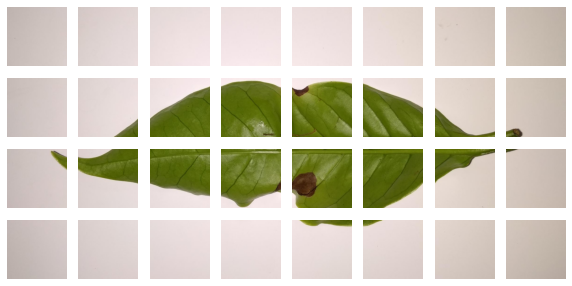

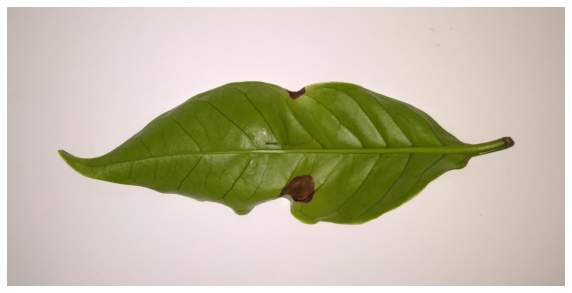

In [5]:
idx = randint(0, len(img_path_list))
patch_size=256

img = cv2.cvtColor(cv2.imread(img_path_list[idx]), cv2.COLOR_BGR2RGB)

patched_img = Patch(img, patch_size)
unpatched_img = Unpatch(patched_img, img.shape)

ncols, nrows = img.shape[1]//patch_size, img.shape[0]//patch_size

gs = GridSpec(nrows, ncols)
fig1 = plt.figure(figsize=(10, 5))
for r in range(nrows):
    for c in range(ncols):
        ax = fig1.add_subplot(gs[r, c])
        ax.imshow(patched_img[(r*ncols+c)])
        ax.axis('off')

plt.figure(figsize=(10, 6))
plt.imshow(unpatched_img)
plt.axis('off')

plt.show()

#### Image Preprocessing

In [16]:
patched_img, patched_mask = [], []
_patch_size = 256

for idx in range(len(img_path_list)):
    _img = cv2.imread(img_path_list[idx])
    _mask = cv2.imread(mask_path_list[idx])
    patched_img.append(Patch(_img, _patch_size))
    patched_mask.append(Patch(_mask, _patch_size))   


patched_img = np.array(patched_img)     # (500, 32, 256, 256, 3)
patched_mask = np.array(patched_mask)

patched_img = np.reshape(patched_img, (-1, *patched_img.shape[2:])) #(16000, 256, 256, 3)
patched_mask = np.reshape(patched_mask, (-1, *patched_mask.shape[2:]))

train_img, test_img, train_mask, test_mask = train_test_split(patched_img, patched_mask, test_size=0.1, shuffle=False)
train_img, val_img, train_mask, val_mask = train_test_split(train_img, train_mask, test_size=0.2, shuffle=False)

#### Image Augmentation

In [ ]:
def Generator(img_arr, mask_arr, gen_kwargs, img_preprocessor, mask_preprocessor, batch_size=32, seed=10):
    Datagen = ImageDataGenerator(**gen_kwargs, preprocessing_function=img_preprocessor)        # preprocess the image to suit the model requirements
    image_generator = Datagen.flow(img_arr, batch_size=batch_size, shuffle=False, seed=seed)   # apply the same seed to ensure the same transormation both for the img and the mask

    Datagen = ImageDataGenerator(**gen_kwargs, preprocessing_function=mask_preprocessor)
    mask_generator = Datagen.flow(mask_arr, batch_size=batch_size, shuffle=False, seed=seed)
    for (img, mask) in zip(image_generator, mask_generator):
        yield (img, mask)
    # return zip(image_generator, mask_generator)

In [ ]:
generator_kwargs = {'rotation_range': 3,
                    'width_shift_range': 0.2,
                    'height_shift_range': 0.2, 
                    'horizontal_flip': True,
                    'vertical_flip': True, 
                    'validation_split': 0.2}

train_generator = Generator(img_arr=train_img, 
                            mask_arr=train_mask, 
                            gen_kwargs=generator_kwargs,
                            img_preprocessor=Normalize, 
                            mask_preprocessor=EncodeLabel,
                            seed=10)

val_generator = Generator(img_arr=val_img, 
                          mask_arr=val_mask, 
                          gen_kwargs=generator_kwargs, 
                          img_preprocessor=Normalize, 
                          mask_preprocessor=EncodeLabel,
                          seed=10)

test_generator = Generator(img_arr=test_img, 
                          mask_arr=test_mask, 
                          gen_kwargs={}, 
                          img_preprocessor=Normalize, 
                          mask_preprocessor=EncodeLabel,
                          seed=None)

In [ ]:
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1.0)


def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)

# def jacard_coef(y_true, y_pred):
#     y_true_f = K.flatten(y_true)
#     y_pred_f = K.flatten(y_pred)
#     intersection = K.sum(y_true_f * y_pred_f)
#     return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)


# def jacard_coef_loss(y_true, y_pred):
#     return -jacard_coef(y_true, y_pred)

#### Vanilla Unet Model

In [ ]:
def ConvBlock(input, n_filters, set_batchnorm=True, set_dropout=False):
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(input)
    if set_batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
    if set_batchnorm:
        x = BatchNormalization()(x)    
    x = Activation('relu')(x)
    if set_dropout:
        x = Dropout(0.2)(x)
    return x

def EncoderBlock(input, n_filters, set_batchnorm=True, set_dropout=False):
    x = ConvBlock(input, n_filters, set_batchnorm, set_dropout)
    p = MaxPooling2D((2, 2))(x)
    return x, p

def DecoderBlock(input, skip_features, n_filters):
    x = Conv2DTranspose(n_filters, (2, 2), strides=2, padding='same')(input)
    x = concatenate([x, skip_features])
    x = ConvBlock(x, n_filters)
    return x


def Unet(input_shape, n_classes, n_filters, set_batchnorm=True, set_dropout=False):
    inputs = Input(input_shape)

    conv1, pool1 = EncoderBlock(inputs, n_filters, set_batchnorm=True, set_dropout=False)
    conv2, pool2 = EncoderBlock(pool1, n_filters*2, set_batchnorm=True, set_dropout=False)
    conv3, pool3 = EncoderBlock(pool2, n_filters*4, set_batchnorm=True, set_dropout=False)
    conv4, pool4 = EncoderBlock(pool3, n_filters*8, set_batchnorm=True, set_dropout=False)

    midconv = ConvBlock(pool4, n_filters*16) # Bottleneck layer

    deconv1 = DecoderBlock(midconv, conv4, n_filters*8)
    deconv2 = DecoderBlock(deconv1, conv3, n_filters*4)
    deconv3 = DecoderBlock(deconv2, conv2, n_filters*2)
    deconv4 = DecoderBlock(deconv3, conv1, n_filters)

    outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(deconv4)

    model = Model(inputs, outputs, name='Vanilla UNet')
    return model

In [ ]:
model = Unet(input_shape=(256, 256, 3), n_filters=64)
print(model.summary())

# model.summary()

In [ ]:
def ConvBlock(input, n_filters, set_batchnorm, dropout):
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(input)
    if set_batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
    if set_batchnorm:
        x = BatchNormalization()(x)    
    x = Activation('relu')(x)
    if dropout > 0:
        x = Dropout(dropout)(x)
    return x

def EncoderBlock(input, n_filters, set_batchnorm, dropout):
    x = ConvBlock(input, n_filters, set_batchnorm, dropout)
    p = MaxPooling2D((2, 2))(x)
    return x, p

def DecoderBlock(input, skip_features, n_filters, set_batchnorm, dropout):
    x = Conv2DTranspose(n_filters, (2, 2), strides=2, padding='same')(input)
    x = concatenate([x, skip_features])
    x = ConvBlock(x, n_filters, set_batchnorm, dropout)
    return x


def Unet(input_shape, n_classes, n_filters, set_batchnorm, dropout):
    inputs = Input(input_shape)

    conv1, pool1 = EncoderBlock(inputs, n_filters, set_batchnorm, dropout)
    conv2, pool2 = EncoderBlock(pool1, n_filters*2, set_batchnorm, dropout)
    conv3, pool3 = EncoderBlock(pool2, n_filters*4, set_batchnorm, dropout)
    conv4, pool4 = EncoderBlock(pool3, n_filters*8, set_batchnorm, dropout)

    midconv = ConvBlock(pool4, n_filters*16, set_batchnorm, dropout) # Bottleneck layer

    deconv1 = DecoderBlock(midconv, conv4, n_filters*8, set_batchnorm, dropout)
    deconv2 = DecoderBlock(deconv1, conv3, n_filters*4, set_batchnorm, dropout)
    deconv3 = DecoderBlock(deconv2, conv2, n_filters*2, set_batchnorm, dropout)
    deconv4 = DecoderBlock(deconv3, conv1, n_filters, set_batchnorm, dropout)

    outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(deconv4)

    model = Model(inputs, outputs, name='Vanilla UNet')
    return model

In [ ]:
model = Unet(input_shape=(256, 256, 3), n_classes=3, n_filters=64, set_batchnorm=False, dropout=0.2)
model.summary()

In [ ]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.001,
                            #    decay_steps=118,####################
                               decay_rate=0.97,
                               staircase=True)
 
model.compile(loss=dice_coef_loss,
              loss=SparseCategoricalFocalLoss(gamma=2),
              optimizer= Adam(learning_rate=lr_schedule),
              metrics=['accuracy', dice_coef])

In [ ]:
num_epochs = 3
check_point = ModelCheckpoint(filepath='./Checkpoints',
                              monitor='',
                              verbose=1,
                              save_best_only=True,
                              save_weights_only=True, 
                              mode='auto',
                              save_freq='epoch')
                              
early_stop = EarlyStopping(monitor='',
                           min_delta=0.001,
                           patience=3,
                           verbose=1)
                           
start = datetime.now() 

hist = model.fit(train_generator,
                 steps_per_epoch =train_generator.n//train_generator.batch_size,
                 epochs = num_epochs,
                 verbose=2,
                 validation_data = val_generator,
                 validation_steps=val_generator.n//val_generator.batch_size,
                 callbacks = [check_point, early_stop])   


stop = datetime.now()
execution_time= stop - start
print(f'Execution time: {execution_time}')

model.save('./SavedModel')                              

In [ ]:
loss, acc = model.evaluate(test_generator, verbose=0)
print("    Test Loss: {:.5f}".format(loss))
print("Test Accuracy: {:.2f}%".format(acc * 100))

### Segmentation Using DeepLabV3+

### Segmentation Using Segmentation Models

### Wnet for Unsupervised Model Based Segmentation

In [ ]:
# def ConvBlock(inputs, n_filters, separable, dropout):
#     if separable:
#         return Sequential(
#             [   
#                 inputs,
#                 SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#                 SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#             ]
#         )
#     else:
#         return Sequential(
#             [   
#                 inputs,
#                 Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#                 Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#             ]
#         )


def ConvBlock(inputs, n_filters, separable=True, dropout=0.3):
    if separable:
        x = SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(inputs)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)

        x = SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)
        return x

    else:
        x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(inputs)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)

        x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)
        return x

def EncoderBlock(inputs, n_filters, separable, dropout):
    x = ConvBlock(inputs, n_filters, separable, dropout)
    p = MaxPooling2D((2, 2))(x)
    return x, p


def DecoderBlock(inputs, skip_features, n_filters, separable, dropout):
    x = UpSampling2D(size=(2, 2), data_format='channels_last')(inputs)
    x = concatenate([x, skip_features])
    x = ConvBlock(x, n_filters, separable, dropout)
    return x

# def WNet(input_shape, n_classes, n_filters, separable, dropout=0.3):
def WNet(input_shape=(256, 256, 3), n_classes=3, n_filters=64):    
    inputs = Input(input_shape)
    
    UEnc_conv1, UEnc_pool1 = EncoderBlock(inputs, n_filters, separable=False, dropout=0.3)
    UEnc_conv2, UEnc_pool2 = EncoderBlock(UEnc_pool1, n_filters*2, separable=True, dropout=0.3)
    UEnc_conv3, UEnc_pool3 = EncoderBlock(UEnc_pool2, n_filters*4, separable=True, dropout=0.3)
    UEnc_conv4, UEnc_pool4 = EncoderBlock(UEnc_pool3, n_filters*8, separable=True, dropout=0.3)

    UEnc_midconv = ConvBlock(UEnc_pool4, n_filters*16, separable=True, dropout=0.3) # Bottleneck layer
    
    UEnc_deconv1 = DecoderBlock(UEnc_midconv, UEnc_conv4, n_filters*8, separable=True, dropout=0.3)
    UEnc_deconv2 = DecoderBlock(UEnc_deconv1, UEnc_conv3, n_filters*4, separable=True, dropout=0.3)
    UEnc_deconv3 = DecoderBlock(UEnc_deconv2, UEnc_conv2, n_filters*2, separable=True, dropout=0.3)
    UEnc_deconv4 = DecoderBlock(UEnc_deconv3, UEnc_conv1, n_filters, separable=False, dropout=0.3)  

    UEnc_outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(UEnc_deconv4)


    UDec_conv1, UDec_pool1 = EncoderBlock(UEnc_outputs, n_filters, separable=False, dropout=0.3)
    UDec_conv2, UDec_pool2 = EncoderBlock(UDec_pool1, n_filters*2, separable=True, dropout=0.3)
    UDec_conv3, UDec_pool3 = EncoderBlock(UDec_pool2, n_filters*4, separable=True, dropout=0.3)
    UDec_conv4, UDec_pool4 = EncoderBlock(UDec_pool3, n_filters*8, separable=True, dropout=0.3)

    UDec_midconv = ConvBlock(UDec_pool4, n_filters*16, separable=True, dropout=0.3) # Bottleneck layer

    UDec_deconv1 = DecoderBlock(UDec_midconv, UDec_conv4, n_filters*8, separable=True, dropout=0.3)
    UDec_deconv2 = DecoderBlock(UDec_deconv1, UDec_conv3, n_filters*4, separable=True, dropout=0.3)
    UDec_deconv3 = DecoderBlock(UDec_deconv2, UDec_conv2, n_filters*2, separable=True, dropout=0.3)
    UDec_deconv4 = DecoderBlock(UDec_deconv3, UDec_conv1, n_filters, separable=False, dropout=0.3)  

    UDec_outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(UDec_deconv4)

    model = Model(inputs=inputs, outputs=UDec_outputs)
    return model

In [ ]:
model = WNet(input_shape=(256, 256, 3), n_classes=3, n_filters=64)
model.summary()

### Custom Data Generator

In [106]:
class DataGenerator(Sequence):

    def __init__(self, df, patch_size, shuffle=True):
        self.df = df.copy()
        self.patch_size = patch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df))

        self.on_epoch_end()

    def __len__(self):
        img_path = self.df['Img Path'].iloc[randint(0, len(self.df))]
        img_shape = imread(img_path).shape
        return (img_shape[0] * img_shape[1]) // (self.patch_size ** 2)

    def on_epoch_end(self):
        if self.shuffle == True:
            np.random.shuffle(self.indexes)
            return self.df.reindex(self.indexes)
    
    def __getitem__(self, index):
        img_path = self.df['Img Path'].iloc[index]
        mask_path = self.df['Mask Path'].iloc[index]

        img, mask = imread(img_path), imread(mask_path)             # load rgb image
        
        transform = A.Compose([A.RandomBrightnessContrast(p=0.25),
                               A.HorizontalFlip(p=0.25),
                               A.VerticalFlip(p=0.25),
                               A.Blur(p=0.25)])

        augmented = transform(image=img, mask=mask)
        augmented_img, augmented_mask = augmented['image'], augmented['mask']

        normalized_img = Normalize(augmented_img)
        encoded_mask = EncodeCatLabel(augmented_mask)

        patched_img, patched_mask = Patch(normalized_img, self.patch_size), Patch(encoded_mask, self.patch_size)
        # return zip(patched_img, patched_mask)      
        return patched_img, patched_mask